# Proyecto 2 IA 

Ing. Luis Suriano

- Vianka Castro 23201
- Ricardo Godinez 23247



## Task 1 Configuración Segura de la Red (CSP y Factor Graphs)

Primero vamos a modelar los grafos, esto asignandoles nodos hermanos. Luego  vamos a asignar protocolos de seguridad a cada nodo. Tenemos 4 protocolos de seguridad disponibles (representados por colores: Rojo, Verde, Azul, Amarillo).

### 1. Modelado: Defina formalmente este problema como un Problema de Satisfacción de Restricciones
(CSP) usando Factor Graphs. ¿Cuáles son sus variables, dominios y factores?

**Variables $X$**:

Las variable son entidades del problema a las que vamos a tener que asignarle un valor. En el caso del proyecto seran los servidores de red.

$X = \{S_0, S_1, S_2, \dots, S_n\}$

Donde n es el numero de nodos generados aleatoriamente

**Dominio $D$**:

El dominio es el conjunto de opciones que puede tomar cada variable, son los 4 protocolos de seguridad disponibles

Para toda variable $S_i$, su dominio inicial es $D_i = \{Rojo, Verde, Azul, Amarillo\}$

**Factores o Restrcciones $D$**:

Este es el concepto de **Factor Graph**. Es un grafo de factores, las reglas del mundo evaluando si es valida o no. En nuestro caso la restriccion fisica de la red es evitar vulnelabilidafes teniendo dos nodos hermanos con el mismo protocolo de red. 

$$
\phi(S_i, S_j) = \begin{cases} 
1 & \text{si } S_i \neq S_j \\ 
0 & \text{si } S_i = S_j 
\end{cases}
$$


### 2. Implementación: Programe desde cero el algoritmo de Backtracking Search.

=== Lista de nodos y conecciones entre ellos
Numero de nodos 17 Numero de vertices 42


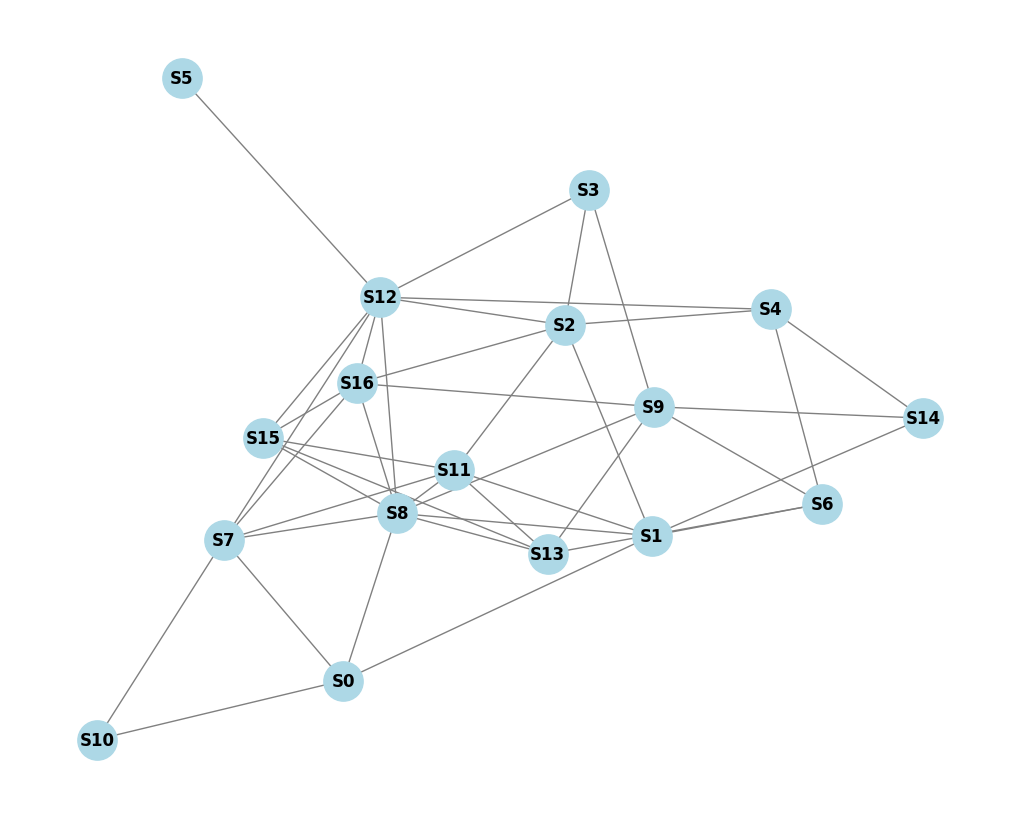

In [1]:
import random
import time
import copy
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

num_nodos = 17
lista_nodos = []

#Creacion de nodos de manera random
for i in range (num_nodos):lista_nodos.append(f"S{i}")

G = nx.Graph()
G.add_nodes_from(lista_nodos)

probabilidad_hermanos = 0.3

# De forma random asignamos a los nodos la probabilidad que un nodo sea su hermano o no
for i in range(num_nodos):
    for j in range(i + 1, num_nodos):
        if random.random() < probabilidad_hermanos:
            G.add_edge(f"S{i}", f"S{j}")

print("=== Lista de nodos y conecciones entre ellos")
print(f"Numero de nodos {G.number_of_nodes()} Numero de vertices {G.number_of_edges()}")
plt.figure(figsize=(10, 8))
nx.draw(G, 
        with_labels=True,        
        node_color='lightblue',  
        node_size=800,           
        font_weight='bold',      
        edge_color='gray')

plt.show()


In [2]:
#Validamos si el protocolo de color que queremos usar ya esta siendo ocupado por un nodo hermano
def es_valido(nodo, color, asignaciones, grafo):
    for vecino in grafo.neighbors(nodo):
        if vecino in asignaciones and asignaciones[vecino] == color:
            return False
    return True

#Definimos el algoritmo de backtracking puro
def backtracking_puro(asignaciones, nodos_pendientes, dominios, grafo):
    if len(asignaciones) == grafo.number_of_nodes():
        return asignaciones

    nodo_actual = nodos_pendientes[0]

    for color in dominios[nodo_actual]:
        if es_valido(nodo_actual, color, asignaciones, grafo):
            asignaciones[nodo_actual] = color
            
            resultado = backtracking_puro(asignaciones, nodos_pendientes[1:], dominios, grafo)
            
            if resultado is not None:
                return resultado

            del asignaciones[nodo_actual]

    return None


protocolos = ["Rojo", "Verde", "Azul", "Amarillo"]
dominios = {}
for nodo in G.nodes():
    dominios[nodo] = protocolos.copy()

asignaciones_iniciales = {}
lista_nodos_pendientes = list(G.nodes())

solucion = backtracking_puro(asignaciones_iniciales, lista_nodos_pendientes, dominios, G)

print("Resultado de la configuración:", solucion)

Resultado de la configuración: {'S0': 'Rojo', 'S1': 'Verde', 'S2': 'Azul', 'S3': 'Rojo', 'S4': 'Rojo', 'S5': 'Rojo', 'S6': 'Azul', 'S7': 'Verde', 'S8': 'Azul', 'S9': 'Verde', 'S10': 'Azul', 'S11': 'Rojo', 'S12': 'Amarillo', 'S13': 'Amarillo', 'S14': 'Azul', 'S15': 'Verde', 'S16': 'Rojo'}


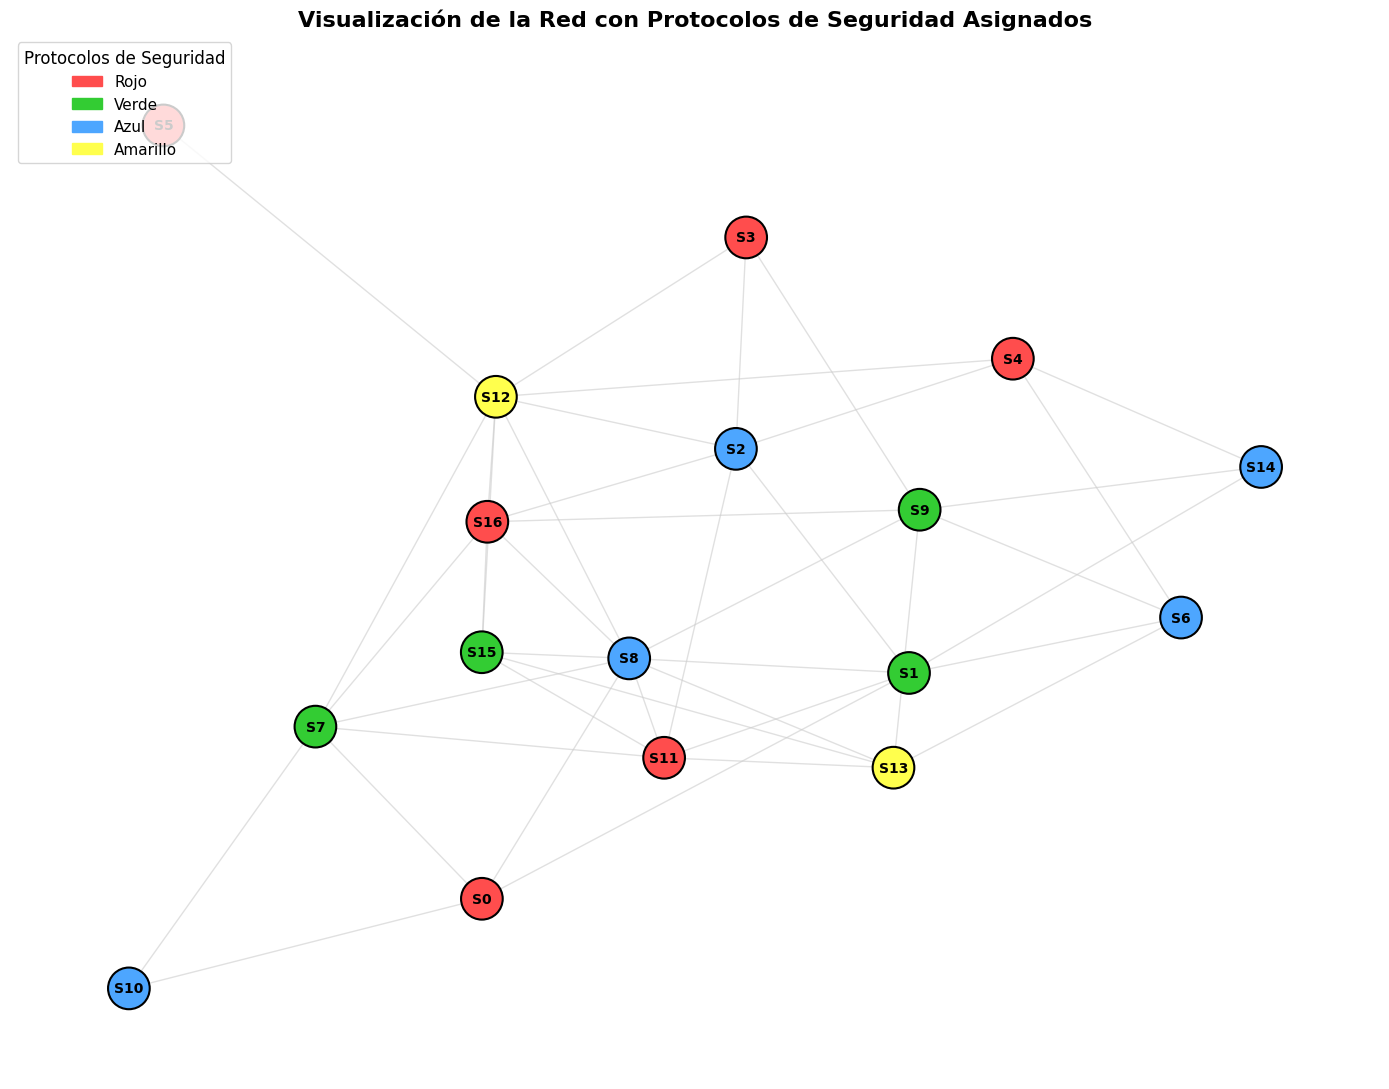

In [3]:
mapa_colores_visual = {
    "Rojo": "#ff4d4d",    
    "Verde": "#33cc33",    
    "Azul": "#4da6ff",     
    "Amarillo": "#ffff4d"  
}

lista_colores_nodos = []

for nodo in G.nodes():
    color_asignado_es = solucion[nodo]
    
    color_matplot = mapa_colores_visual[color_asignado_es] 
    lista_colores_nodos.append(color_matplot)

plt.figure(figsize=(14, 11))
plt.title("Visualización de la Red con Protocolos de Seguridad Asignados", fontsize=16, fontweight='bold')
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_edges(G, pos, 
                       edge_color='#cccccc', 
                       width=1.0, 
                       alpha=0.6)

nx.draw_networkx_nodes(G, pos, 
                       node_color=lista_colores_nodos,
                       node_size=900, 
                       edgecolors='black',
                       linewidths=1.5)

nx.draw_networkx_labels(G, pos, 
                        font_size=10, 
                        font_family='sans-serif', 
                        font_weight='bold',
                        font_color='black') 


patches_leyenda = []
for protocolo, color_hex in mapa_colores_visual.items():
    parche = mpatches.Patch(color=color_hex, label=protocolo)
    patches_leyenda.append(parche)

plt.legend(handles=patches_leyenda, title="Protocolos de Seguridad", fontsize=11, title_fontsize=12, loc='upper left')

plt.axis('off') 
plt.tight_layout() 
plt.show()

### 3. Optimización: Su algoritmo básico será muy lento. Debe implementar obligatoriamente:

a. Lookahead (Forward Checking): Para eliminar dominios inconsistentes de los vecinos.

b. Heurística MCV (Minimum Remaining Values / Variable más restringida): Para elegir el siguiente nodo a asignar.

In [4]:
def backtracking_optimizado(grafo, dominios, nodos_pendientes, asignaciones):
    if not nodos_pendientes:
        return asignaciones

    nodo_actual = min(nodos_pendientes, key=lambda n: len(dominios[n]))
    nodos_pendientes = [n for n in nodos_pendientes if n != nodo_actual]

    for color in dominios[nodo_actual]:
        dominios_futuros = copy.deepcopy(dominios)
        falla_futura = False
    
        for vecino in grafo.neighbors(nodo_actual):
            if vecino in nodos_pendientes:
                if color in dominios_futuros[vecino]:
                    dominios_futuros[vecino].remove(color)

                if len(dominios_futuros[vecino]) == 0:
                    falla_futura = True
                    break
    
            if not falla_futura:
                asignaciones[nodo_actual] = color
                resultado = backtracking_optimizado(grafo, dominios_futuros, nodos_pendientes, asignaciones)

                if resultado is not None:
                    return asignaciones

                del asignaciones[nodo_actual]

    return None


protocolos = ["Rojo", "Verde", "Azul", "Amarillo"]
lista_nodos_pendientes = list(G.nodes())

asignaciones_optimizadas = {}
dominios_optimizados = {}
for nodo in G.nodes():
    dominios_optimizados[nodo] = protocolos.copy()

solucion_optimizada = backtracking_optimizado(G, dominios_optimizados, lista_nodos_pendientes, asignaciones_optimizadas)

print("Resultado de la configuración:", solucion)

Resultado de la configuración: {'S0': 'Rojo', 'S1': 'Verde', 'S2': 'Azul', 'S3': 'Rojo', 'S4': 'Rojo', 'S5': 'Rojo', 'S6': 'Azul', 'S7': 'Verde', 'S8': 'Azul', 'S9': 'Verde', 'S10': 'Azul', 'S11': 'Rojo', 'S12': 'Amarillo', 'S13': 'Amarillo', 'S14': 'Azul', 'S15': 'Verde', 'S16': 'Rojo'}


### 4 Análisis
En su reporte, demuestre con métricas (tiempo de ejecución o número de asignaciones intentadas) la diferencia de rendimiento entre su Backtracking "puro" y su Backtracking optimizado con MCV y Lookahead.

In [5]:
protocolos = ["Rojo", "Verde", "Azul", "Amarillo"]
lista_nodos_pendientes = list(G.nodes())

asignaciones_puras = {}
dominios_puros = {}
for nodo in G.nodes():
    dominios_puros[nodo] = protocolos.copy()

print("Iniciando algoritmo puro...")
tiempo_inicio = time.perf_counter()

solucion = backtracking_puro(asignaciones_puras, lista_nodos_pendientes, dominios_puros, G)

tiempo_fin = time.perf_counter() 
tiempo_total_puro = tiempo_fin - tiempo_inicio

print(f"¡Red asegurada con éxito! (Puro)")
print(f"Tiempo de ejecución: {tiempo_total_puro:.5f} segundos")

asignaciones_optimizadas = {}
dominios_optimizados = {}
for nodo in G.nodes():
    dominios_optimizados[nodo] = protocolos.copy()

print("Iniciando algoritmo optimizado...")
tiempo_inicio = time.perf_counter() 

solucion_optimizada = backtracking_optimizado(G, dominios_optimizados, lista_nodos_pendientes, asignaciones_optimizadas)

tiempo_fin = time.perf_counter() 
tiempo_total_opt = tiempo_fin - tiempo_inicio

print(f"¡Red asegurada con éxito! (Optimizado)")
print(f"Tiempo de ejecución: {tiempo_total_opt:.5f} segundos\n")

Iniciando algoritmo puro...
¡Red asegurada con éxito! (Puro)
Tiempo de ejecución: 0.04224 segundos
Iniciando algoritmo optimizado...
¡Red asegurada con éxito! (Optimizado)
Tiempo de ejecución: 0.00301 segundos



Los resultados demuestran que el algoritmo optimizado es aproximadamente 3.75 veces más rápido que el enfoque puro de fuerza bruta. Esta mejora drástica en el tiempo de ejecución no es accidental, sino el resultado directo de la poda del árbol de búsqueda mediante dos técnicas:

La Heurística MCV (Minimum Remaining Values / Variable más restringida):
El Backtracking puro selecciona el siguiente servidor a configurar simplemente basándose en su orden de aparición en la lista. En contraste, la heurística MCV aplica el principio de "fallar primero". Al elegir proactivamente el servidor que tiene la menor cantidad de protocolos legales disponibles, el algoritmo aborda los cuellos de botella de la red de inmediato. Esto minimiza enormemente el factor de ramificación en la parte superior del árbol de recursión.

Lookahead (Forward Checking):
El algoritmo puro sufre de "evaluación tardía": asigna un color y solo se da cuenta de que fue un error varias recursiones después, obligándolo a retroceder (backtrack) perdiendo tiempo valioso. El enfoque con Lookahead implementa la propagación de restricciones. Cada vez que se asigna un protocolo a un servidor, el algoritmo "mira hacia el futuro" y elimina esa opción de los dominios de todos sus vecinos. Si un vecino se queda sin opciones (dominio vacío), el algoritmo aborta esa rama inmediatamente, podando miles de combinaciones inconsistentes antes de siquiera intentar explorarlas.

# Task 2 – Defensa Adversarial (Juegos de Suma Cero)

La red ha sido configurada y está operativa. El juego ahora es por turnos. En cada turno, un jugador puede **"capturar" un nodo adyacente** a los que ya controla. 
- **MAX (Defensa)** 
- **MIN (Atacante / Hacker)** 

Cada nodo tiene un **"Valor de Información"** aleatorio. El objetivo de la defensa es maximizar la información asegurada (o la diferencia a su favor), mientras que el atacante intenta contrarrestarlo.

### 1. Implementación de Minimax
A continuación se define la lógica base del algoritmo Minimax para predecir los mejores movimientos de la Defensa (MAX).

In [6]:
import random

# Definimos los valores de información de cada nodo de 10 a 100 de forma aleatoria (Simulación)
valores_informacion = {nodo: random.randint(10, 100) for nodo in G.nodes()}

print("Valores de Información de los Nodos:")
for nodo, valor in sorted(valores_informacion.items()):
    print(f"{nodo}: {valor}")

def obtener_movimientos_posibles(grafo, nodos_jugador, nodos_globales_capturados):
    """
    Retorna una lista de nodos libres que son adyacentes a los nodos ya controlados por el jugador.
    
    :param grafo: Grafo de NetworkX.
    :param nodos_jugador: Set de nodos controlados por el jugador que tienen el turno.
    :param nodos_globales_capturados: Set de todos los nodos ya capturados (Defensa + Hacker).
    :return: Lista de nodos disponibles para captura.
    """
    movimientos = set()
    for nodo in nodos_jugador:
        for vecino in grafo.neighbors(nodo):
            if vecino not in nodos_globales_capturados:
                movimientos.add(vecino)
    return list(movimientos)

def minimax(grafo, valores_informacion, nodos_max, nodos_min, turnos_restantes, es_turno_max):
    """
    Algoritmo Minimax para decidir el mejor nodo a capturar para MAX (Defensa).
    Retorna una tupla: (Mejor Valor Obtenido, Mejor Nodo a Capturar).
    
    :param grafo: Grafo de NetworkX representando la red.
    :param valores_informacion: Diccionario con el valor de cada nodo.
    :param nodos_max: Set con los nodos capturados por la Defensa (MAX).
    :param nodos_min: Set con los nodos capturados por el Hacker (MIN).
    :param turnos_restantes: Condición de parada (Profundidad en el árbol).
    :param es_turno_max: Booleano que indica si es el turno de MAX o MIN.
    :return: (valor, movimiento)
    """
    nodos_capturados = nodos_max.union(nodos_min)
    
    # Condición de parada: Se alcanzó el límite de turnos o ya no hay nodos libres en la red.
    if turnos_restantes == 0 or len(nodos_capturados) == len(grafo.nodes()):
        # Función de evaluación: Valor total capturado por MAX menos Valor total capturado por MIN
        score_max = sum(valores_informacion[n] for n in nodos_max)
        score_min = sum(valores_informacion[n] for n in nodos_min)
        return score_max - score_min, None

    if es_turno_max: # 🛡️ Turno de la Defensa (MAX)
        mejor_valor = -float('inf')
        mejor_movimiento = None
        movimientos = obtener_movimientos_posibles(grafo, nodos_max, nodos_capturados)
        
        # Si MAX no tiene movimientos posibles, pierde su turno y le toca a MIN
        if not movimientos:
            valor, _ = minimax(grafo, valores_informacion, nodos_max, nodos_min, turnos_restantes - 1, False)
            return valor, None
            
        for mov in movimientos:
            # Simular movimiento de MAX
            nuevos_nodos_max = nodos_max.copy()
            nuevos_nodos_max.add(mov)
            
            # Llamada recursiva, pasando turno a MIN
            valor_actual, _ = minimax(grafo, valores_informacion, nuevos_nodos_max, nodos_min, turnos_restantes - 1, False)
            
            # Nos quedamos con el valor máximo para MAX
            if valor_actual > mejor_valor:
                mejor_valor = valor_actual
                mejor_movimiento = mov
                
        return mejor_valor, mejor_movimiento

    else:           # ☠️ Turno del Hacker (MIN)
        mejor_valor = float('inf')
        mejor_movimiento = None
        movimientos = obtener_movimientos_posibles(grafo, nodos_min, nodos_capturados)
        
        # Si MIN no tiene movimientos posibles, pierde su turno y le toca a MAX
        if not movimientos:
            valor, _ = minimax(grafo, valores_informacion, nodos_max, nodos_min, turnos_restantes - 1, True)
            return valor, None
            
        for mov in movimientos:
            # Simular movimiento de MIN
            nuevos_nodos_min = nodos_min.copy()
            nuevos_nodos_min.add(mov)
            
            # Llamada recursiva, pasando turno a MAX
            valor_actual, _ = minimax(grafo, valores_informacion, nodos_max, nuevos_nodos_min, turnos_restantes - 1, True)
            
            # Nos quedamos con el valor mínimo para simular que MIN actúa de forma óptima
            if valor_actual < mejor_valor:
                mejor_valor = valor_actual
                mejor_movimiento = mov
                
        return mejor_valor, mejor_movimiento

print("\n(Minimax cargado. Listo para definir las condiciones iniciales del juego en el próximo paso)")

Valores de Información de los Nodos:
S0: 74
S1: 39
S10: 27
S11: 50
S12: 66
S13: 85
S14: 34
S15: 99
S16: 69
S2: 44
S3: 65
S4: 16
S5: 11
S6: 94
S7: 23
S8: 72
S9: 94

(Minimax cargado. Listo para definir las condiciones iniciales del juego en el próximo paso)


### Task 2 – Defensa Adversarial (Juegos de Suma Cero)

A continuación, implementaremos la **Poda Alfa-Beta** sobre nuestra función de **Minimax**, e incluiremos contadores para medir los nodos expandidos por ambos algoritmos.

#### 1. y 2. Implementación de Minimax con y sin Poda Alfa-Beta
Se ha estructurado el código de manera que se cuenten las llamadas recursivas (nodos expandidos) para comparar.

#### 3. Función de Evaluación Heurística `Eval(s)`
La función de evaluación limitará la búsqueda a una profundidad máxima (`d_max = 4`) y evalúa los estados intermedios.
**Función `Eval(s)`**: 
$$Eval(s) = \sum_{n \in Nodos_{MAX}} Valor(n) - \sum_{n \in Nodos_{MIN}} Valor(n)$$

#### 4.a Análisis de la Función de Evaluación
*   **Explicación Matemática**: La función calcula la diferencia neta entre los valores de información asegurados por MAX y los asegurados por MIN en un estado $s$ dado. 
*   **Por qué es una buena aproximación**: Al tratarse de un juego de suma cero donde cada punto sumado a MAX es perdido por MIN (y al revés de cara al total de la red), la diferencia de puntuación hasta el momento es el indicador más directo de ventaja. Al no poder explorar hasta el final, esta heurística asume que los valores ya capturados son "seguros" e incentiva decisiones que capturen nodos con valores más altos inmediatamente, priorizando también bloquear que MIN sume el valor de nodos adyacentes de gran peso.

In [7]:
# Reiniciar los valores de información de inicio como en su código anterior, si no están definidos
import random
# Simulamos nodos controlados inicialmente por Defensa y Hacker (ej: dos nodos lejanos o iniciales)
inicio_defensa = {list(G.nodes())[0]}
inicio_hacker = {list(G.nodes())[-1]}
profundidad_maxima = 4 # Nivel máximo requerido, simulando d_max=4

# Variables globales para contar nodos explorados en ambos algoritmos
nodos_expandidos_minimax = 0
nodos_expandidos_alfabeta = 0

def evaluar_estado(valores_informacion, nodos_max, nodos_min):
    """ Función Heurística Eval(s) """
    score_max = sum(valores_informacion[n] for n in nodos_max)
    score_min = sum(valores_informacion[n] for n in nodos_min)
    return score_max - score_min

def minimax_puro(grafo, valores_informacion, nodos_max, nodos_min, profundidad, es_turno_max):
    """ Minimax Base (contando nodos) """
    global nodos_expandidos_minimax
    nodos_expandidos_minimax += 1
    
    nodos_capturados = nodos_max.union(nodos_min)
    
    # Parada (límite de profundidad o todos capturados)
    if profundidad == 0 or len(nodos_capturados) == len(grafo.nodes()):
        return evaluar_estado(valores_informacion, nodos_max, nodos_min), None

    movimientos = obtener_movimientos_posibles(grafo, nodos_max if es_turno_max else nodos_min, nodos_capturados)
    
    if not movimientos:
        # Pasa turno
        valor, _ = minimax_puro(grafo, valores_informacion, nodos_max, nodos_min, profundidad - 1, not es_turno_max)
        return valor, None
        
    if es_turno_max:
        mejor_valor = -float('inf')
        mejor_movimiento = None
        for mov in movimientos:
            nuevos_nodos_max = nodos_max.copy()
            nuevos_nodos_max.add(mov)
            valor_actual, _ = minimax_puro(grafo, valores_informacion, nuevos_nodos_max, nodos_min, profundidad - 1, False)
            if valor_actual > mejor_valor:
                mejor_valor = valor_actual
                mejor_movimiento = mov
        return mejor_valor, mejor_movimiento
    else:
        mejor_valor = float('inf')
        mejor_movimiento = None
        for mov in movimientos:
            nuevos_nodos_min = nodos_min.copy()
            nuevos_nodos_min.add(mov)
            valor_actual, _ = minimax_puro(grafo, valores_informacion, nodos_max, nuevos_nodos_min, profundidad - 1, True)
            if valor_actual < mejor_valor:
                mejor_valor = valor_actual
                mejor_movimiento = mov
        return mejor_valor, mejor_movimiento

def minimax_alfabeta(grafo, valores_informacion, nodos_max, nodos_min, profundidad, alfa, beta, es_turno_max):
    """ Minimax Optimizado con Poda Alfa-Beta (contando nodos) """
    global nodos_expandidos_alfabeta
    nodos_expandidos_alfabeta += 1
    
    nodos_capturados = nodos_max.union(nodos_min)
    
    # Parada
    if profundidad == 0 or len(nodos_capturados) == len(grafo.nodes()):
        return evaluar_estado(valores_informacion, nodos_max, nodos_min), None

    movimientos = obtener_movimientos_posibles(grafo, nodos_max if es_turno_max else nodos_min, nodos_capturados)
    
    if not movimientos:
        # Pasa turno
        valor, _ = minimax_alfabeta(grafo, valores_informacion, nodos_max, nodos_min, profundidad - 1, alfa, beta, not es_turno_max)
        return valor, None
        
    if es_turno_max:
        mejor_valor = -float('inf')
        mejor_movimiento = None
        for mov in movimientos:
            nuevos_nodos_max = nodos_max.copy()
            nuevos_nodos_max.add(mov)
            valor_actual, _ = minimax_alfabeta(grafo, valores_informacion, nuevos_nodos_max, nodos_min, profundidad - 1, alfa, beta, False)
            
            if valor_actual > mejor_valor:
                mejor_valor = valor_actual
                mejor_movimiento = mov
            alfa = max(alfa, mejor_valor)
            if beta <= alfa:
                break  # Poda Beta
        return mejor_valor, mejor_movimiento
    else:
        mejor_valor = float('inf')
        mejor_movimiento = None
        for mov in movimientos:
            nuevos_nodos_min = nodos_min.copy()
            nuevos_nodos_min.add(mov)
            valor_actual, _ = minimax_alfabeta(grafo, valores_informacion, nodos_max, nuevos_nodos_min, profundidad - 1, alfa, beta, True)
            
            if valor_actual < mejor_valor:
                mejor_valor = valor_actual
                mejor_movimiento = mov
            beta = min(beta, mejor_valor)
            if beta <= alfa:
                break  # Poda Alfa
        return mejor_valor, mejor_movimiento

# ================= 4b. Comparación de Nodos =================
print("=== Turno de Prueba para Comparación ===")
# Reseteamos variables
nodos_expandidos_minimax = 0
nodos_expandidos_alfabeta = 0

# Test Minimax Puro
val_m, mov_m = minimax_puro(G, valores_informacion, inicio_defensa, inicio_hacker, profundidad_maxima, True)
# Test Minimax Alfa-Beta
val_ab, mov_ab = minimax_alfabeta(G, valores_informacion, inicio_defensa, inicio_hacker, profundidad_maxima, -float('inf'), float('inf'), True)

print(f"Profundidad Límite d_max: {profundidad_maxima}")
print(f"Resultado Valor Esperado (Puro VS AlfaBeta): {val_m} == {val_ab}")
print(f"Movimiento para Defensa: {mov_m}")
print(f"Número de nodos expandidos por Minimax Puro: {nodos_expandidos_minimax}")
print(f"Número de nodos expandidos con Poda Alfa-Beta: {nodos_expandidos_alfabeta}")

ahorro = (1 - (nodos_expandidos_alfabeta / max(nodos_expandidos_minimax, 1))) * 100
print(f"Porcentaje de nodos reducidos gracias a la poda: {ahorro:.2f}%")

=== Turno de Prueba para Comparación ===
Profundidad Límite d_max: 4
Resultado Valor Esperado (Puro VS AlfaBeta): -13 == -13
Movimiento para Defensa: S8
Número de nodos expandidos por Minimax Puro: 917
Número de nodos expandidos con Poda Alfa-Beta: 312
Porcentaje de nodos reducidos gracias a la poda: 65.98%
